# SKKU 2024 Challenge
## Dicke State Preparation

In [1]:
import numpy as np
import qiskit
from qiskit_aer import Aer

from qiskit.circuit.library import QFT
from qiskit import transpile

In [2]:
## utils.py
backend = Aer.get_backend("aer_simulator")
backend2 = Aer.get_backend("statevector_simulator")

### Part 1

#### a)

The Hamiltonian whose eigenvalues differs by Hamming weight in $n$-qubit system can be constructed by the projector onto the space of fixed Hamming weight $i$. That is,
$$
\mathcal{H} = \sum_{i=0}^{2^n -1} e_i P_{i}
$$
The eigenvalue $e_i$ can be freely chosen, without repeatation. For example, we can choose $e_i = i$ where the eigenvalue is just the Hamming weight $i$.
Note that the given hamiltonian can have ${}_{n}C_{i}$ for $e_i$.

#### b) 
Let $k$ denote the minimum number of bits required to measure hamming weight of the state. Then
$$
k = \left[\log_{2}(n+1)\right]
$$
where $\left[ a \right]$ denotes the smallest integer larger than $a$.

### Part 2

In [3]:
def HammingWeight(vector):
	n = np.log2(vector.shape[0]).astype(np.int64) # num of physical qubits
	k = np.ceil(np.log2(n+1)).astype(np.int64)
	N = 2**k - 1
	#w = 2**k - (n+1)

	#qc = qiskit.QuantumCircuit(n + k + w, k) # q_0 to q_{k-1} is for measurement, q_{k} to q_{k+n-1} are for state.
	qc = qiskit.QuantumCircuit(n + k, k) # q_0 to q_{k-1} is for measurement, q_{k} to q_{k+n-1} are for state.
	
	#print(n, k, N, w)
 
	state_computation = qiskit.QuantumCircuit(k)
	for i in range(k):
		state_computation.h(i)
 
	state_preparation = qiskit.QuantumCircuit(n)
	state_preparation.initialize(vector, state_preparation.qubits)
 
	#print([i for i in range(0,k,1)])
	#print([i for i in range(k,k+n,1)])	
 
	qc = qc.compose(state_computation, qubits=[i for i in range(0,k,1)])
	qc = qc.compose(state_preparation, qubits=[i for i in range(k,k+n,1)])

	for i in range(0,k):
		theta = n*np.pi/(N+1)*2**i
		#theta = N*np.pi/(N+1)*2**i
		qc.rz(theta, i)

	for i in range(k-1,-1,-1):
		theta = 2*np.pi/(N+1) * 2**i
		#theta = 2*np.pi/(N+1) * 2**i
		#for j in range(k+n+w-1,k-1,-1):
		for j in range(k+n-1,k-1,-1):
			print(i,j)
			qc.crz(theta, i, j)
   
	#IQFT = QFT(num_qubits=k, inverse=True).to_gate()
	#qc.append(IQFT, qargs=[i for i in range(0,k,1)])
 
	# IQFT
	for i in range(k-1, -1, -1):
		for j in range(k-1, i, -1):
			theta = -2*np.pi / 2**(j-i+1)
			qc.crz(theta, j, i)
		qc.h(i)
			

	for i in range(k):
		qc.measure(i,k-i-1)
		
   
	return qc

In [4]:
test_vec = np.ones(8)/np.sqrt(8)
#test_vec = np.zeros(4)
#test_vec[0] = 1/np.sqrt(2)
#test_vec[3] = 1/np.sqrt(2)
#test_vec[6] = 1/np.sqrt(3)
#test_vec[5] = 1

test_qc = HammingWeight(test_vec)

1 4
1 3
1 2
0 4
0 3
0 2


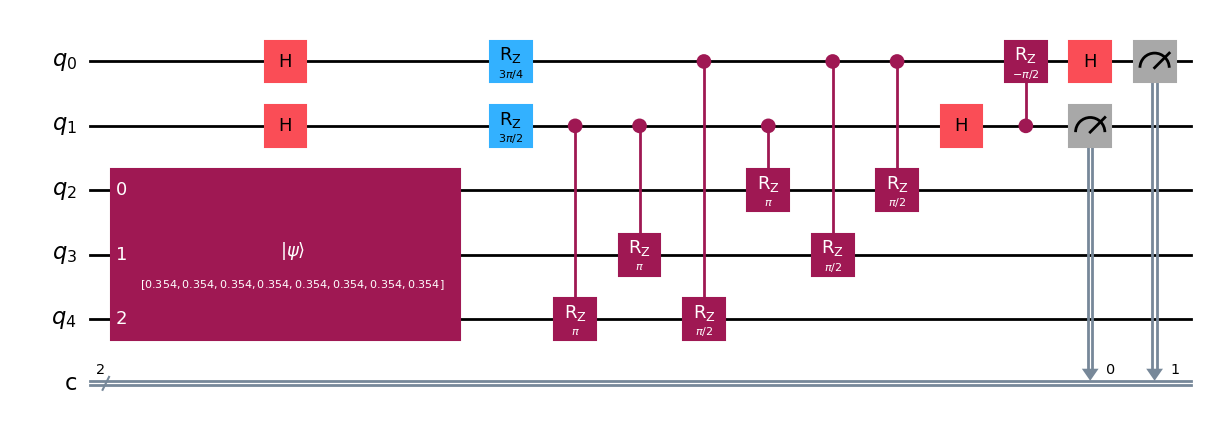

In [5]:
test_qc.draw(output="mpl")

In [18]:
result = backend.run(test_qc, shots=8**3).result()
result.data()

#result = backend2.run(test_qc).result()
#result.get_statevector()

{'counts': {'0x1': 185, '0x0': 66, '0x2': 196, '0x3': 65}}

### Part 3

### Part 4
